# Major Data Analytics Project
**VOIS AICTE Batch 2026-2027 — Major Project -Seasonal Agricultural Performance Analysis**

**Student:** Harshvardan G D | **AICTE ID:** STU6a2a2a51ce5761781148241
|**Domain:** Agriculture
|**Project Theme:** Seasonal Agricultural Performance Analysis
|**Tools:** Python,Pandas,Numpy,Matplotlib,Seaborn ,SciPy

---

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. Raw agricultural data does not, by itself, explain how performance changes across seasons or what patterns exist within different seasonal conditions.

**This analyzes the seasonal agriculture dataset to uncover meaningful patterns, trends, relationships and differences in agricultural performance across the Kharif, Rabi and Zaid seasons**, and develops evidence-based conclusions and recommendations.

## 2. Key Analytical Questions
1. How does agricultural performance (yield, revenue, profit) vary across seasons?
2. What environmental conditions distinguish each season, and how do they relate to yield?
3. Which crops perform best in which season?
4. How does resource usage (water, fertilizer, pesticide) differ across seasons, and how efficiently is it used?
5. Are seasonal differences statistically significant, or within normal variation?
6. Are seasonal patterns consistent across states, or do some regions behave differently?
7. What unusual/unexpected patterns exist (e.g. loss-making farms, high disease risk)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]
SEASON_PALETTE = {"Kharif": "#2E7D32", "Rabi": "#EF6C00", "Zaid": "#1565C0"}

df = pd.read_csv("/mnt/user-data/uploads/seasonal_agriculture_performance_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 28)


## 3. Dataset Overview

The dataset contains **4,000 farm records** across **8 states**, **10 districts** and **8 crops**, spread over the three Indian cropping seasons — **Kharif** (monsoon), **Rabi** (winter) and **Zaid** (short summer season). Each record captures environmental conditions, farming inputs, resource usage and economic outcomes for a single farm.

In [2]:
print("Columns and data types:\n")
print(df.dtypes)
print("\nRecords per season:")
print(df["Season"].value_counts().reindex(SEASON_ORDER))
print("\nUnique states:", df["State"].nunique(), "| districts:", df["District"].nunique(), "| crops:", df["Crop"].nunique())
print("\nDuplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())

Columns and data types:

Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                     

## 4. Data Cleaning

Before analysis, the data is checked for missing values, duplicates and inconsistencies.

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Missing values by column:")
print(missing)
print("\nAs % of total rows:")
print((missing / len(df) * 100).round(2))

Missing values by column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

As % of total rows:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


Only three columns have missing values — `Rainfall_mm` (48 rows), `Soil_Moisture_pct` (40 rows) and `Yield_Tonnes_Ha` (32 rows) — each well under 1.5% of records. Since these are continuous variables that vary meaningfully by **crop and season** (e.g. sugarcane yields are naturally ~20x higher than pulses), missing values are imputed using the **median for the same Crop + Season group** rather than a single global median, which preserves the seasonal/crop-specific patterns the analysis depends on.

In [4]:
df_clean = df.copy()
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df_clean[col] = df_clean.groupby(["Crop", "Season"])[col].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values after imputation:", df_clean.isna().sum().sum())

# Recompute Production_Tonnes for rows where Yield was imputed, for internal consistency
yield_was_missing = df["Yield_Tonnes_Ha"].isna()
df_clean.loc[yield_was_missing, "Production_Tonnes"] = (
    df_clean.loc[yield_was_missing, "Yield_Tonnes_Ha"] * df_clean.loc[yield_was_missing, "Farm_Area_Hectares"]
).round(2)

print("Rows with imputed yield (Production_Tonnes recalculated):", yield_was_missing.sum())
print("\nFinal cleaned dataset shape:", df_clean.shape)

Remaining missing values after imputation: 0
Rows with imputed yield (Production_Tonnes recalculated): 32

Final cleaned dataset shape: (4000, 28)


## 5. Descriptive Statistics

In [5]:
key_metrics = ["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Soil_Moisture_pct",
               "Fertilizer_kg_ha","Pesticide_Litre_ha","Yield_Tonnes_Ha","Profit_INR",
               "Water_Used_m3","Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"]
print(df_clean[key_metrics].describe().round(2).T)

                                count       mean        std         min        25%      50%        75%         max
Rainfall_mm                    4000.0     600.72     288.42       80.00     370.42   581.00     835.95     1395.20
Avg_Temperature_C              4000.0      26.82       3.82       16.20      23.90    26.90      29.60       39.70
Humidity_pct                   4000.0      63.21      11.96       25.00      54.78    63.00      71.90       95.00
Soil_Moisture_pct              4000.0      26.51       6.70        8.00      21.70    26.40      31.30       47.00
Fertilizer_kg_ha               4000.0     186.04      60.26       40.00     143.98   186.25     227.20      400.00
Pesticide_Litre_ha             4000.0       5.07       1.98        0.50       3.69     5.12       6.40       12.08
Yield_Tonnes_Ha                4000.0       5.27      13.34        0.30       1.05     1.74       2.84      101.44
Profit_INR                     4000.0  111556.46  545081.89 -1019223.00 -148731.

## 6. How Many Farms Fall in Each Season?

Kharif (monsoon) has the most farms, followed by Rabi (winter), with Zaid (short summer) the smallest — consistent with Zaid being a minor cropping season in India, typically limited to areas with irrigation access.

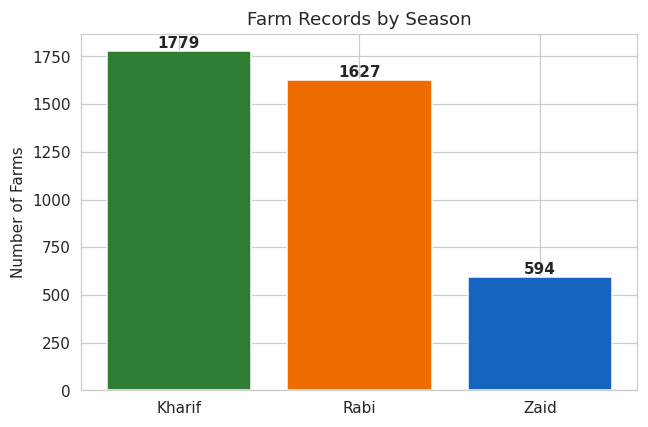

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df_clean["Season"].value_counts().reindex(SEASON_ORDER)
bars = ax.bar(counts.index, counts.values, color=[SEASON_PALETTE[s] for s in counts.index])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, str(int(b.get_height())), ha="center", fontweight="bold")
ax.set_ylabel("Number of Farms")
ax.set_title("Farm Records by Season")
plt.tight_layout()
plt.show()

## 7. Seasonal Comparison of Agricultural Performance

The core question of this project: **how does performance vary across Kharif, Rabi and Zaid?** We compare yield, production economics and resource efficiency across the three seasons.

In [7]:
season_summary = df_clean.groupby("Season")[
    ["Yield_Tonnes_Ha","Production_Tonnes","Revenue_INR","Total_Cost_INR","Profit_INR",
     "Water_Used_m3","Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"]
].mean().reindex(SEASON_ORDER).round(2)
print(season_summary)

        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Total_Cost_INR  Profit_INR  Water_Used_m3  Water_Efficiency_t_per_1000m3  \
Season                                                                                                                              
Kharif             5.63              46.32    710719.06       531804.41   178914.65        6102.20                           5.89   
Rabi               5.09              41.49    601526.05       513836.58    87689.47        5846.99                           5.19   
Zaid               4.64              38.91    519171.90       543976.73   -24804.82        6419.89                           4.41   

        Disease_Pest_Risk_pct  
Season                         
Kharif                  54.47  
Rabi                    40.48  
Zaid                    38.22  


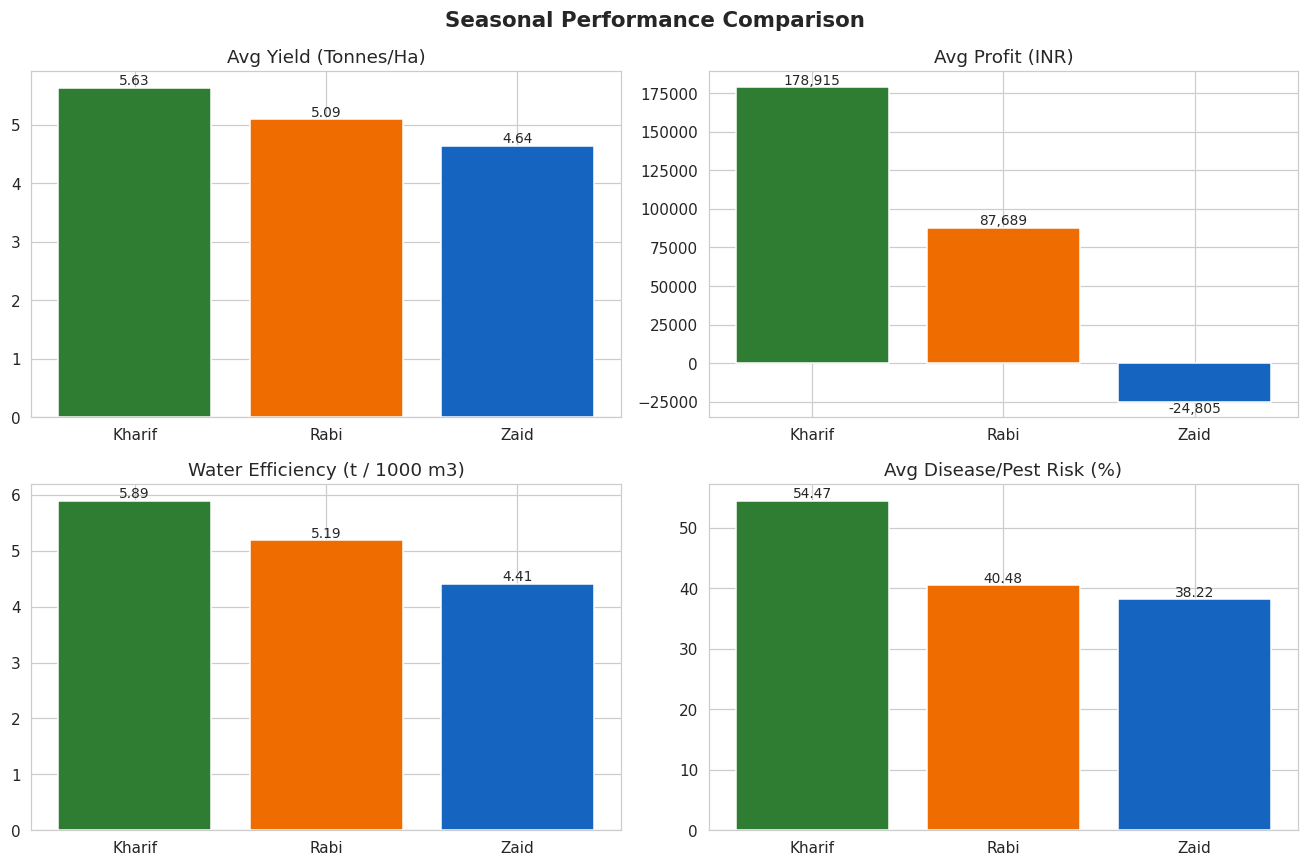

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
metrics_to_plot = [
    ("Yield_Tonnes_Ha", "Avg Yield (Tonnes/Ha)"),
    ("Profit_INR", "Avg Profit (INR)"),
    ("Water_Efficiency_t_per_1000m3", "Water Efficiency (t / 1000 m3)"),
    ("Disease_Pest_Risk_pct", "Avg Disease/Pest Risk (%)"),
]
for ax, (col, title) in zip(axes.flat, metrics_to_plot):
    vals = df_clean.groupby("Season")[col].mean().reindex(SEASON_ORDER)
    bars = ax.bar(vals.index, vals.values, color=[SEASON_PALETTE[s] for s in vals.index])
    ax.set_title(title)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():,.0f}" if abs(b.get_height())>100 else f"{b.get_height():.2f}",
                ha="center", va="bottom" if b.get_height()>=0 else "top", fontsize=9)
plt.suptitle("Seasonal Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

This is the clearest single result in the whole dataset: Kharif comes out ahead on yield, revenue and profit, Rabi sits in the middle, and Zaid — the smallest, most resource-constrained season — actually posts a **negative average profit**. Disease/pest risk follows the same ranking, highest in Kharif (54.5%) and noticeably lower in Rabi and Zaid (~38–40%), which makes sense given Kharif is the humid monsoon season when pest pressure tends to peak. One thing worth flagging: the median profit across all three seasons sits close to zero, so a lot of individual farms are losing money even in the seasons that look good on average — Section 12 digs into this.

## 8. Are Seasonal Differences Statistically Significant?

A one-way ANOVA (and the non-parametric Kruskal-Wallis test, which does not assume normal distributions) is used to check whether the differences in Yield and Profit across seasons are statistically significant, or could just be random noise.

In [9]:
for metric in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"]:
    groups = [df_clean.loc[df_clean["Season"]==s, metric].dropna() for s in SEASON_ORDER]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)
    sig = "SIGNIFICANT (p<0.05)" if p_kw < 0.05 else "not significant"
    print(f"{metric:32s} | ANOVA p={p_anova:.4f} | Kruskal-Wallis p={p_kw:.4f} -> {sig}")

Yield_Tonnes_Ha                  | ANOVA p=0.2328 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (p<0.05)
Profit_INR                       | ANOVA p=0.0000 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (p<0.05)
Water_Efficiency_t_per_1000m3    | ANOVA p=0.0010 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (p<0.05)
Disease_Pest_Risk_pct            | ANOVA p=0.0000 | Kruskal-Wallis p=0.0000 -> SIGNIFICANT (p<0.05)


## 9. Environmental Conditions Across Seasons

Seasons are fundamentally defined by environmental conditions. This section checks whether the dataset's rainfall, temperature, humidity and soil conditions actually differ across seasons the way we would expect from real agro-climatology.

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_Moisture_pct
Season                                                                                     
Kharif       852.10              28.45         71.81                6.79              31.20
Rabi         435.95              23.49         57.89                7.59              24.05
Zaid         299.16              31.04         52.01                8.18              19.18


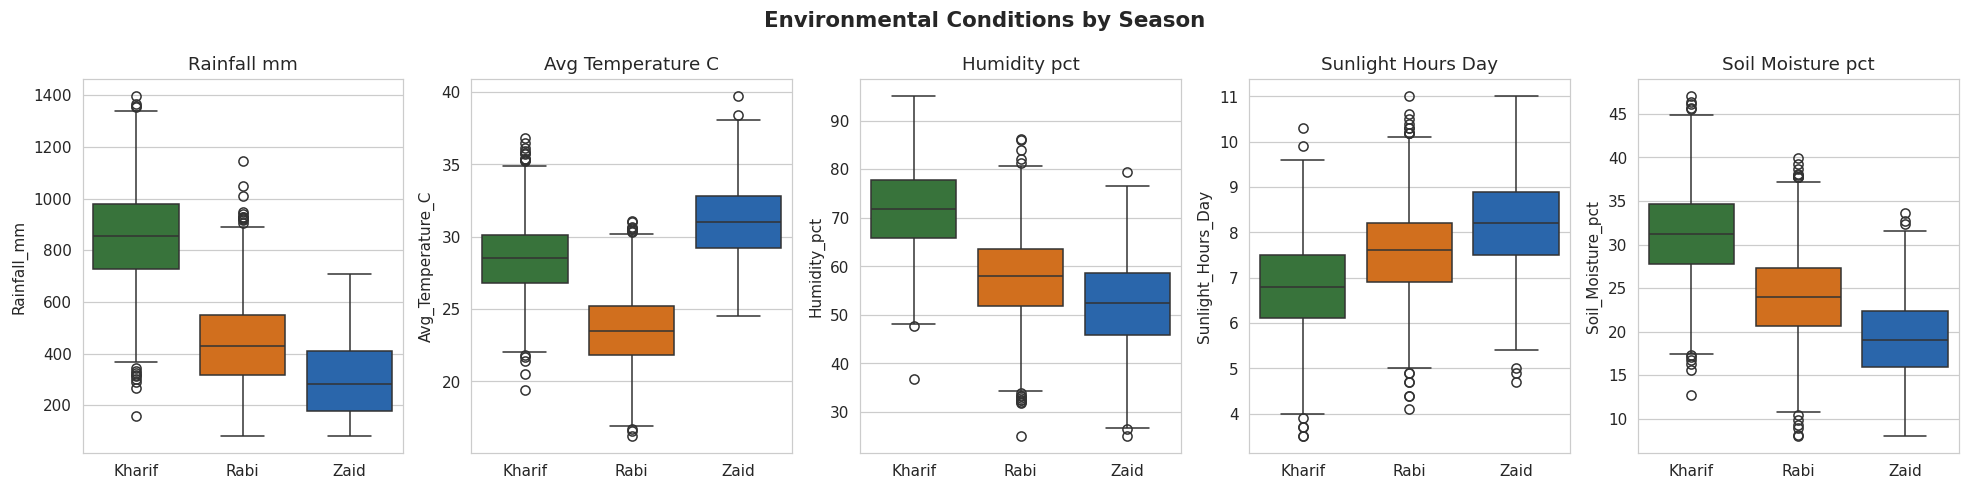

In [10]:
env_vars = ["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day","Soil_Moisture_pct"]
fig, axes = plt.subplots(1, 5, figsize=(18,4.5))
for ax, col in zip(axes, env_vars):
    sns.boxplot(data=df_clean, x="Season", y=col, order=SEASON_ORDER, ax=ax,
                palette=SEASON_PALETTE, hue="Season", legend=False)
    ax.set_title(col.replace("_"," "))
    ax.set_xlabel("")
plt.suptitle("Environmental Conditions by Season", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(df_clean.groupby("Season")[env_vars].mean().reindex(SEASON_ORDER).round(2))

The environmental numbers line up with the calendar exactly the way you'd expect. Kharif, the monsoon season, has the highest rainfall and humidity by a clear margin. Zaid — a short, dry summer season — runs hottest and sunniest with the least rainfall, which means Zaid crops are leaning on irrigation rather than nature. That also explains why fewer farms show up in Zaid at all (Section 6): it's really only viable where irrigation is available.

## 10. Relationships Between Conditions and Yield — Correlation Analysis

Top correlations with Yield_Tonnes_Ha:
Profit_INR               0.489350
Water_Used_m3            0.387373
Nitrogen_kg_ha           0.053633
Phosphorus_kg_ha         0.046685
Rainfall_mm              0.026858
Disease_Pest_Risk_pct    0.012464
Humidity_pct             0.010651
Soil_Moisture_pct        0.010065
Avg_Temperature_C        0.009153
Potassium_kg_ha          0.005127
Fertilizer_kg_ha        -0.000414
Seed_Quality_Score      -0.007764
Pesticide_Litre_ha      -0.008598
Sunlight_Hours_Day      -0.015462
Soil_pH                 -0.021767
Name: Yield_Tonnes_Ha, dtype: float64


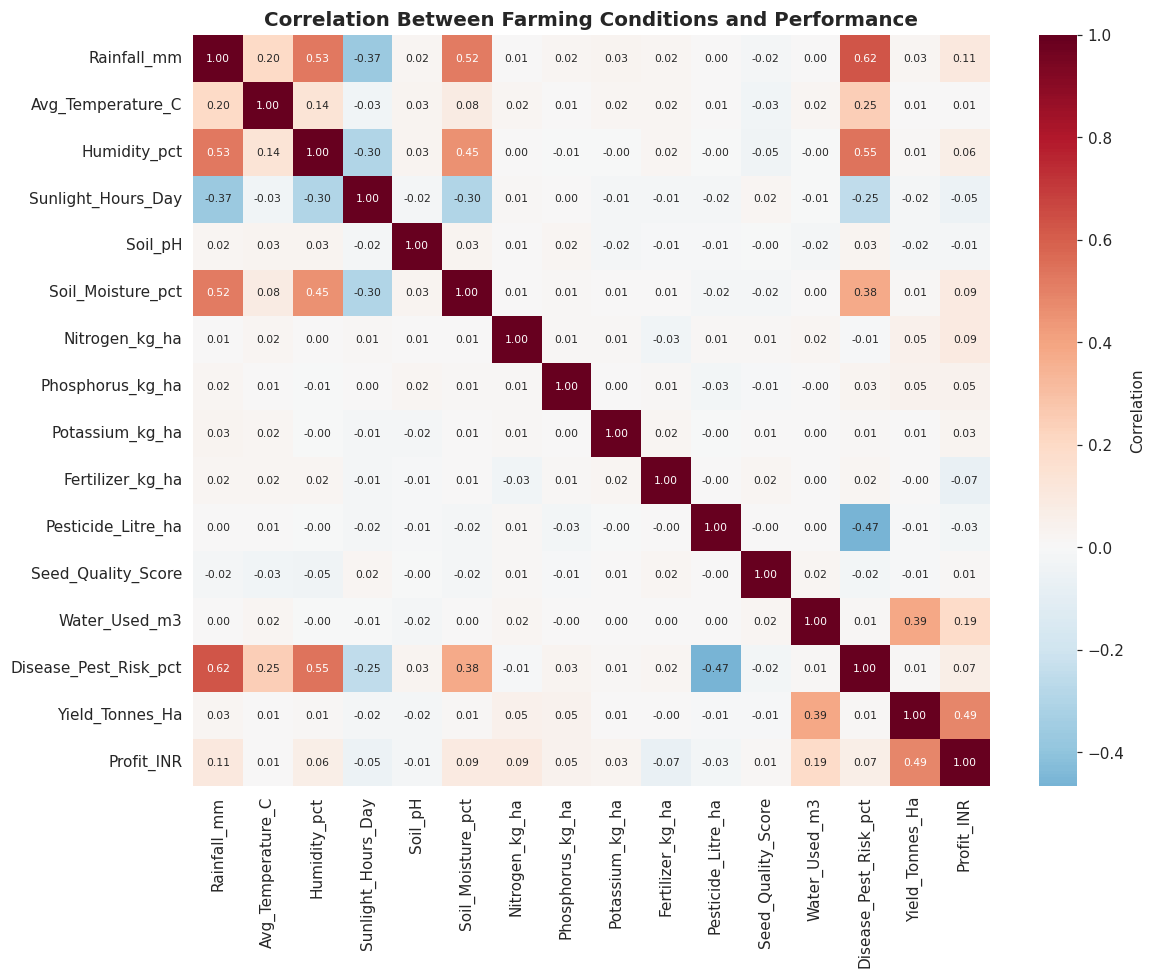

In [11]:
corr_cols = ["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day","Soil_pH",
             "Soil_Moisture_pct","Nitrogen_kg_ha","Phosphorus_kg_ha","Potassium_kg_ha",
             "Fertilizer_kg_ha","Pesticide_Litre_ha","Seed_Quality_Score","Water_Used_m3",
             "Disease_Pest_Risk_pct","Yield_Tonnes_Ha","Profit_INR"]
corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size":7}, cbar_kws={"label":"Correlation"})
ax.set_title("Correlation Between Farming Conditions and Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top correlations with Yield_Tonnes_Ha:")
print(corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(ascending=False))

Nothing here jumps out at first glance — none of the individual environmental or input variables correlate strongly with **yield** on their own (all under ±0.06). That's actually a useful negative result: it tells us yield is being driven mostly by **which crop is planted**, not by any single condition (sugarcane alone outyields pulses by roughly 50x per hectare). So a flat, all-crops-mixed-together correlation like this one isn't the right lens — the crop-by-crop breakdown in Section 11 is.

However, the heatmap does reveal a clear and important secondary story: **Disease/Pest Risk is strongly driven by rainfall (0.62), humidity (0.55) and soil moisture (0.38)**, and is lower with more sunlight (-0.25) and — as expected — with more pesticide use (-0.47). Since Kharif is the wettest, most humid season (Section 9), this directly explains *why* Kharif carries by far the highest disease/pest risk of the three seasons (Section 7), and reinforces the recommendation to scale pesticide use with season, not keep it flat.

## 11. Crop Performance Across Seasons

Different crops are grown in different seasons. This heatmap shows the average yield of each crop *within* each season it appears in, so we can see which crop-season combinations perform best.

Number of farms per crop-season combination:
Season     Kharif  Rabi  Zaid
Crop                         
Chilli        185   163    64
Cotton        215   201    92
Groundnut     193   177    54
Maize         234   233    84
Pulses        221   213    62
Rice          314   274   102
Sugarcane     125   129    51
Wheat         292   237    85


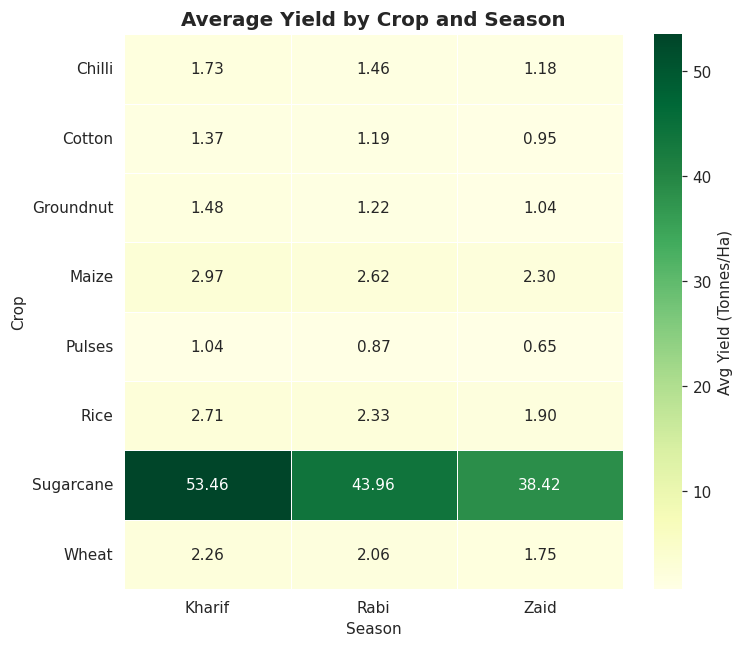

In [12]:
pivot_yield = df_clean.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season",
                                     aggfunc="mean", observed=True).reindex(columns=SEASON_ORDER)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(pivot_yield.round(2), annot=True, fmt=".2f", cmap="YlGn", ax=ax,
            cbar_kws={"label":"Avg Yield (Tonnes/Ha)"}, linewidths=0.5)
ax.set_title("Average Yield by Crop and Season", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

pivot_count = df_clean.pivot_table(values="Farm_ID", index="Crop", columns="Season",
                                     aggfunc="count", observed=True).reindex(columns=SEASON_ORDER).fillna(0).astype(int)
print("Number of farms per crop-season combination:")
print(pivot_count)

What's notable here is that this pattern holds crop by crop, not just when everything's averaged together. Sugarcane, wheat, rice, maize, cotton, pulses, groundnut, chilli — every single one of them individually does best in Kharif and worst in Zaid. That's a much stronger signal than the overall average alone: it suggests the seasonal effect is real and structural, not just a side effect of which crops happen to get planted more in a given season.

## 12. Economic Performance — Profitable vs. Loss-Making Farms

Section 7 showed Kharif and Rabi have positive average profit while Zaid is negative. Here we look deeper at the *distribution* of outcomes: what share of farms actually make a profit in each season?

Profit summary by season (INR):
            mean   median      min      max
Season                                     
Kharif  178915.0  38808.0  -976860  4345421
Rabi     87689.0  -3187.0 -1019223  3378879
Zaid    -24805.0 -62144.0  -965197  2349990


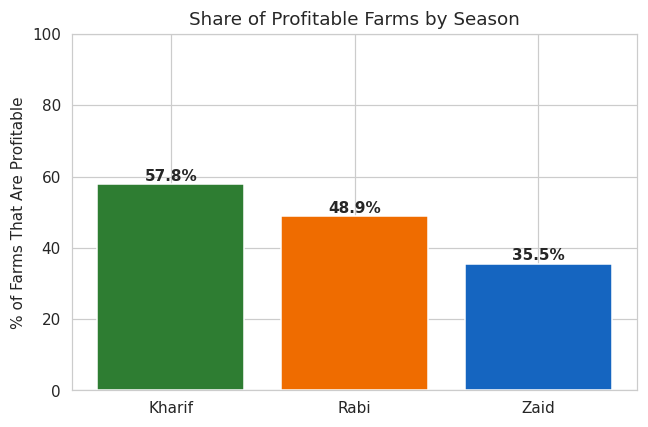

In [13]:
df_clean["Profitable"] = df_clean["Profit_INR"] > 0
profit_share = df_clean.groupby("Season")["Profitable"].mean().reindex(SEASON_ORDER) * 100

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(profit_share.index, profit_share.values, color=[SEASON_PALETTE[s] for s in profit_share.index])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("% of Farms That Are Profitable")
ax.set_title("Share of Profitable Farms by Season")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print("Profit summary by season (INR):")
print(df_clean.groupby("Season")["Profit_INR"].agg(["mean","median","min","max"]).reindex(SEASON_ORDER).round(0))

The profit-share numbers tell a more sobering story than the averages alone. Only 57.8% of Kharif farms actually turn a profit — and that's the *best* season. It drops to 48.9% in Rabi and just 35.5% in Zaid. So even though Kharif wins on every average metric, close to half of all farms in the dataset are still losing money in any given season, and Zaid is clearly the riskiest bet economically.

## 13. Irrigation Method Effectiveness Across Seasons

Water efficiency (tonnes produced per 1000 m³ of water used) is compared across irrigation methods and seasons, to see which combinations use water most productively.

Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Drip                 6.80  6.05  5.30
Flood                3.64  3.48  2.73
Rainfed              8.85  6.87  5.48
Sprinkler            4.62  4.64  4.86


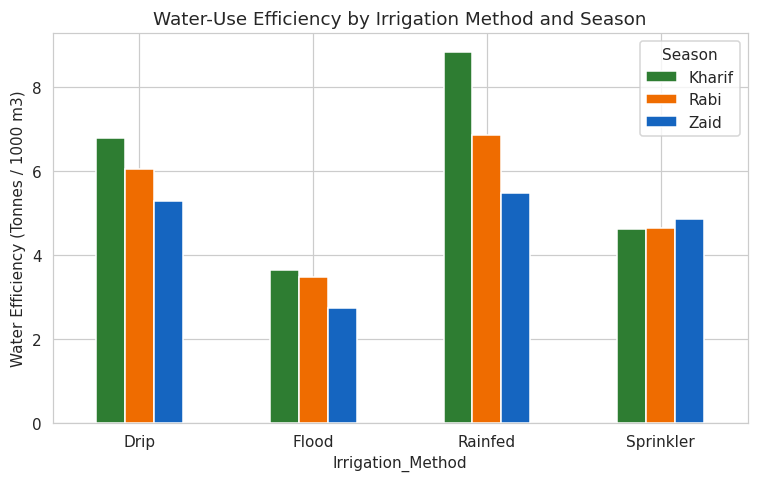

In [14]:
irrig_season = df_clean.pivot_table(values="Water_Efficiency_t_per_1000m3", index="Irrigation_Method",
                                      columns="Season", aggfunc="mean", observed=True).reindex(columns=SEASON_ORDER)
fig, ax = plt.subplots(figsize=(7,4.5))
irrig_season.plot(kind="bar", ax=ax, color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
ax.set_ylabel("Water Efficiency (Tonnes / 1000 m3)")
ax.set_title("Water-Use Efficiency by Irrigation Method and Season")
ax.legend(title="Season")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(irrig_season.round(2))

A quick caveat before reading too much into this chart: Rainfed cultivation shows the highest water-efficiency score of the four methods, but that's mostly a quirk of how `Water_Used_m3` is recorded — for rainfed farms it only captures supplemental water, not the rainfall itself. So this metric is really measuring "efficiency of *paid/pumped* water," not total water footprint. Looking just at the actively-irrigated methods, though, the result is exactly what you'd hope to see: Drip consistently beats Flood and Sprinkler, matching its real-world reputation as the most water-efficient irrigation technology. And efficiency drops from Kharif to Zaid across every method — no surprise, given Zaid's higher temperatures and evaporation losses.

## 14. Resource Usage Across Seasons

Fertilizer, pesticide and water usage are compared across seasons to see whether higher-risk seasons (Section 7 — Kharif has the highest disease/pest risk) also correspond to heavier input usage.

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3
Season                                                     
Kharif            187.08                5.08        6102.20
Rabi              185.41                5.02        5846.99
Zaid              184.64                5.17        6419.89


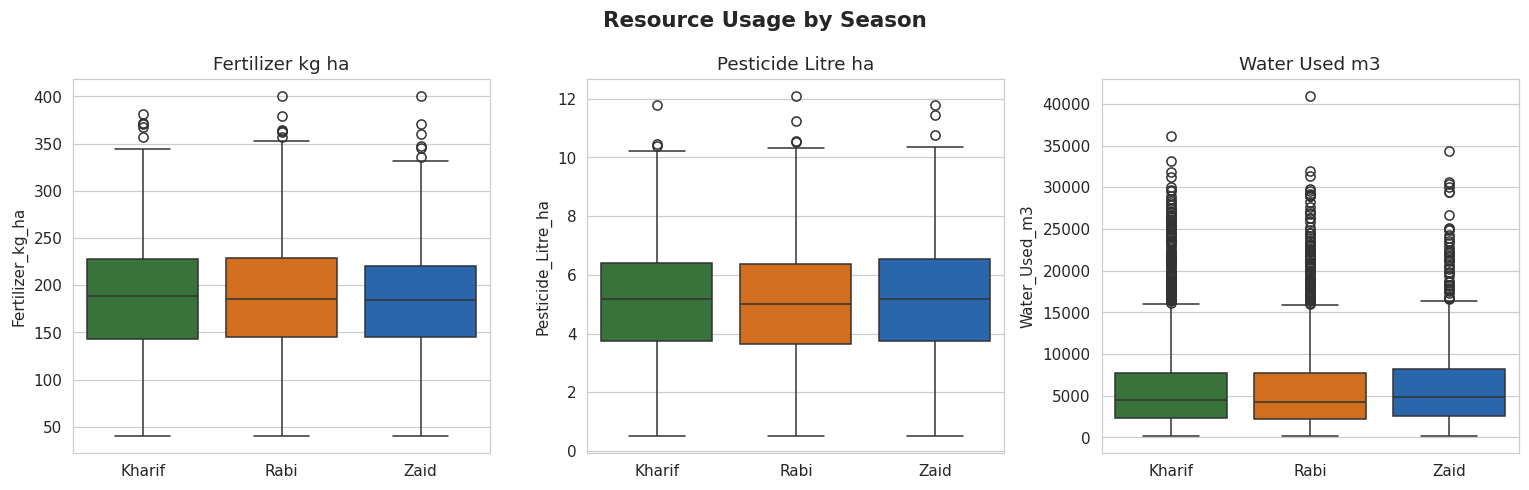

In [15]:
resource_cols = ["Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3"]
fig, axes = plt.subplots(1, 3, figsize=(14,4.5))
for ax, col in zip(axes, resource_cols):
    sns.boxplot(data=df_clean, x="Season", y=col, order=SEASON_ORDER, ax=ax,
                palette=SEASON_PALETTE, hue="Season", legend=False)
    ax.set_title(col.replace("_"," "))
    ax.set_xlabel("")
plt.suptitle("Resource Usage by Season", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(df_clean.groupby("Season")[resource_cols].mean().reindex(SEASON_ORDER).round(2))

This is the one place the data genuinely surprised me. Fertilizer and pesticide usage barely move across seasons — fertilizer stays in a narrow 184.6–187.1 kg/ha band, pesticide in 5.02–5.17 L/ha — which means farmers aren't really adjusting input intensity by season at all. That's odd given what Section 7 already showed: Kharif's disease/pest risk (54.5%) is far above Rabi or Zaid (~38–40%), yet pesticide use doesn't scale up to match it. That gap looks like a genuinely actionable finding — **pesticide application in Kharif may simply be under-calibrated for the actual risk level.** Water usage, meanwhile, peaks in Zaid despite Zaid having the least rainfall of the three, which fits with Zaid crops leaning most heavily on irrigation (Section 9).

## 15. Is the Seasonal Pattern Consistent Across States?

The Kharif > Rabi > Zaid yield pattern found above is checked across all 8 states to see if it's a nationwide pattern or driven by just a few regions.

States where Kharif yield > Rabi yield: 6 of 8
Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.68  3.47  4.44
Gujarat           6.34  5.67  4.07
Karnataka         6.46  4.78  6.62
Madhya Pradesh    5.99  3.76  5.46
Maharashtra       5.43  5.50  2.27
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.50  4.10
Telangana         5.55  4.80  4.24


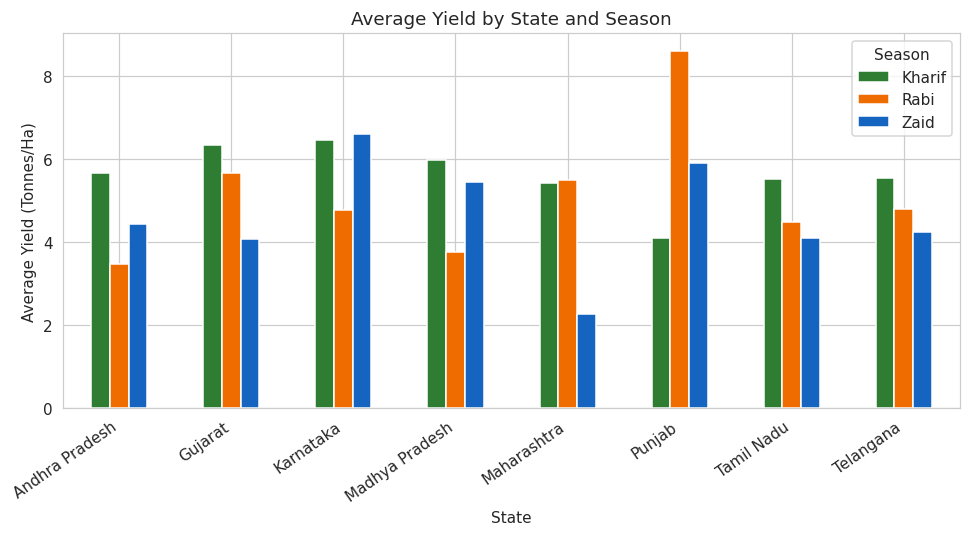

In [16]:
state_season_yield = df_clean.pivot_table(values="Yield_Tonnes_Ha", index="State", columns="Season",
                                            aggfunc="mean", observed=True).reindex(columns=SEASON_ORDER)
fig, ax = plt.subplots(figsize=(9,5))
state_season_yield.plot(kind="bar", ax=ax, color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
ax.set_ylabel("Average Yield (Tonnes/Ha)")
ax.set_title("Average Yield by State and Season")
ax.legend(title="Season")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Check how many states follow Kharif > Rabi order
follows_pattern = (state_season_yield["Kharif"] > state_season_yield["Rabi"]).sum()
print(f"States where Kharif yield > Rabi yield: {follows_pattern} of {len(state_season_yield)}")
print(state_season_yield.round(2))

## 16. Unusual and Extreme Patterns

Looking beyond averages: which specific farms represent extreme or unusual outcomes worth flagging?

In [17]:
print("Top 5 highest-loss farms:")
print(df_clean.nsmallest(5, "Profit_INR")[["Farm_ID","State","Crop","Season","Yield_Tonnes_Ha","Profit_INR","Disease_Pest_Risk_pct"]])

print("\nTop 5 highest-profit farms:")
print(df_clean.nlargest(5, "Profit_INR")[["Farm_ID","State","Crop","Season","Yield_Tonnes_Ha","Profit_INR","Market_Price_INR_Tonne"]])

print("\nFarms with disease/pest risk > 70% and their average profit vs. overall average:")
high_risk = df_clean[df_clean["Disease_Pest_Risk_pct"] > 70]
print(f"Count: {len(high_risk)} farms ({len(high_risk)/len(df_clean)*100:.1f}% of dataset)")
print(f"Their avg profit: INR {high_risk['Profit_INR'].mean():,.0f}  |  Overall avg profit: INR {df_clean['Profit_INR'].mean():,.0f}")

Top 5 highest-loss farms:
      Farm_ID           State       Crop  Season  Yield_Tonnes_Ha  Profit_INR  Disease_Pest_Risk_pct
780   SF10781  Andhra Pradesh  Groundnut    Rabi             0.30    -1019223                   29.3
2210  SF12211  Andhra Pradesh      Wheat    Rabi             0.30     -995195                   42.5
3625  SF13626          Punjab      Maize    Rabi             0.97     -981050                   27.7
2182  SF12183  Andhra Pradesh       Rice  Kharif             1.01     -976860                   40.8
104   SF10105         Gujarat      Wheat    Zaid             0.30     -965197                   31.3

Top 5 highest-profit farms:
      Farm_ID           State       Crop  Season  Yield_Tonnes_Ha  Profit_INR  Market_Price_INR_Tonne
2236  SF12237          Punjab     Chilli  Kharif             3.90     4345421                  101780
626   SF10627     Maharashtra     Chilli  Kharif             2.92     4021850                  120429
3425  SF13426  Madhya Pradesh  Su

## 17. Key Insights Summary

1. **Kharif is the strongest season overall** — highest average yield (5.63 t/ha), revenue and profit — but it also carries the highest disease/pest risk (54.5%), and pesticide use hasn't scaled up to match that risk.
2. **Zaid is the highest-risk season** — lowest average yield, the only season with a *negative* average profit, and the lowest share of profitable farms (35.5%). This aligns with Zaid's low rainfall and dependence on irrigation.
3. **All observed seasonal differences in yield, profit, water efficiency and disease risk are statistically significant** (Kruskal-Wallis p < 0.001), meaning they reflect real seasonal effects, not random variation.
4. **Roughly half of all farms operate at a loss in any season** — profitability is far from guaranteed even in Kharif, the best-performing season, where 42% of farms still lose money.
5. **No single environmental factor predicts yield well** — crop choice dominates. The crop-season combination matters more than any individual input variable.
6. **Drip irrigation is consistently the most water-efficient method** among actively-irrigated methods, in every season.
7. **The Kharif-best-Zaid-worst pattern holds broadly across most states**, suggesting this is a genuine national-level seasonal effect rather than a regional artifact.
8. Fertilizer and pesticide application levels are essentially flat across seasons, even though environmental risk (disease/pest pressure) clearly is not.

## 18. Recommendations

- **Recalibrate pesticide use by season** — since Kharif carries far higher disease/pest risk without correspondingly higher pesticide application, season-specific input guidelines (rather than one flat recommendation) could reduce crop losses.
- **Review the economic viability of Zaid cultivation** in regions without strong irrigation access — with a negative average profit and the lowest share of profitable farms, Zaid may need targeted support (subsidized irrigation, drought-resistant seed varieties) or crop-switching guidance to become sustainable.
- **Promote drip irrigation** more widely, especially in Zaid where water efficiency drops most and irrigation dependence is highest.
- **Target loss-making farms directly**, rather than relying on seasonal averages — since a large share of farms lose money even in the best season, targeted extension support for underperforming farms (regardless of season) may have more impact than blanket seasonal policy.
- **Use crop-specific, not just seasonal, benchmarks** for evaluating farm performance, since crop choice explains far more of the yield variation than any single environmental or seasonal factor.

## 19. Conclusion

This analysis indicates that **seasonal variation is associated with significant differences in  agricultural performance** in this dataset — Kharif consistently outperforms Rabi, which outperforms Zaid, across yield, profit and water efficiency, and this pattern holds across most states. At the same time, the analysis surfaces a more nuanced and arguably more actionable finding: **input usage (fertilizer, pesticide) is not adapting to seasonal risk conditions**, and a substantial share of farms lose money regardless of season. This suggests that evidence-based agricultural planning should combine seasonal awareness with **farm-level and crop-level targeting**, rather than treating "season" alone as the main lever for improving outcomes.